# **Dataset**

In [ ]:
# load dataset
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
drug_reviews_druglib_com = fetch_ucirepo(id=461)

# data (as pandas dataframes)
X = drug_reviews_druglib_com.data.features

# metadata
print(drug_reviews_druglib_com.metadata)

# variable information
print(drug_reviews_druglib_com.variables)


{'uci_id': 461, 'name': 'Drug Reviews (Druglib.com)', 'repository_url': 'https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com', 'data_url': 'https://archive.ics.uci.edu/static/public/461/data.csv', 'abstract': 'The dataset provides patient reviews on specific drugs along with related conditions. Reviews and ratings are grouped into reports on the three aspects benefits, side effects and overall comment.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Text'], 'num_instances': 4143, 'num_features': 8, 'feature_types': ['Integer'], 'demographics': [], 'target_col': None, 'index_col': ['reviewID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C55G6J', 'creators': ['Surya Kallumadi', 'Felix Grer'], 'intro_paper': {'ID': 457, 'type': 'NATIVE', 'title': 'Aspect-Based Sentiment Analysis of D

# **Preprocessing**
From the dataset, we can have:
*   `benefitsReview` → Benefit aspect
*   `sideEffectsReview` → Side Effects aspect
*   `commentsReview` → General/Overall aspect

Also:
*   `effectiveness` (categorical: Highly Effective, Marginally Effective, etc.) → sentiment label for benefits
*   `sideEffects` (categorical: Severe, Mild, None) → sentiment label for side effects

In [ ]:
import os, random, gc
import numpy as np
import pandas as pd
from collections import Counter

In [ ]:
# Clean Reviews
import unicodedata, re

def basic_clean(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)                       # collapse spaces
    s = re.sub(r"(.)\1{2,}", r"\1\1\1", s)           # cooool -> coool
    s = re.sub(r"http\S+|www\.\S+", "<url>", s)      # URLs
    s = re.sub(r"@\w+", "<user>", s)                 # handles
    s = re.sub(r"\b\d+(\.\d+)?\b", "<num>", s)       # numbers -> <num>
    # keep ! ? ' for negation/sentiment
    return s

In [ ]:
# Map numeric ratings → sentiment (neg, neu, pos)
# second try
def map_rating(r):
    if r <= 3:    return "negative"
    elif r <= 7:  return "neutral"
    elif r <= 10: return "positive"
    else: return None

X['sentiment'] = X['rating'].apply(map_rating)

In [ ]:
# simple mapping
def map_side_effects(val):
    if "No Side Effects" in val:                  return "positive"
    elif "Mild Side Effects" in val:              return "neutral"
    elif "Moderate Side Effects" in val:          return "negative"
    elif "Severe Side Effects" in val:            return "negative"
    elif "Extremely Severe Side Effects" in val:  return "negative"
    else: return None

X['side_sentiment'] = X['sideEffects'].apply(map_side_effects)

In [ ]:
# simple mapping
def map_effectiveness(val):
    if "Highly Effective" in val:           return "positive"
    elif "Considerably Effective" in val:   return "positive"
    elif "Moderately Effective" in val:     return "neutral"
    elif "Marginally Effective" in val:     return "neutral"
    elif "Ineffective" in val:              return "negative"
    else: return None

X['benefit_sentiment'] = X['effectiveness'].apply(map_effectiveness)

In [ ]:
df = X.copy()

df['comments_clean'] = df['commentsReview'].apply(basic_clean)
df['benefits_clean'] = df['benefitsReview'].apply(basic_clean)
df['side_clean']     = df['sideEffectsReview'].apply(basic_clean)


df['label_comments'] = df['rating'].apply(map_rating)
df['label_benefits'] = df['effectiveness'].apply(map_effectiveness)
df['label_side']     = df['sideEffects'].apply(map_side_effects)

df = df.dropna(subset=['comments_clean','benefits_clean','side_clean',
                       'label_comments','label_benefits','label_side']).reset_index(drop=True)


In [ ]:
# quick sanity checks
print(df[['label_comments','label_benefits','label_side']].head(3))
print("Counts:")
print("comments:", df['label_comments'].value_counts().to_dict())
print("benefits:", df['label_benefits'].value_counts().to_dict())
print("side    :", df['label_side'].value_counts().to_dict())

  label_comments label_benefits label_side
0        neutral       positive    neutral
1       negative       positive   negative
2       positive       positive   positive
Counts:
comments: {'positive': 2329, 'neutral': 1063, 'negative': 751}
benefits: {'positive': 2979, 'neutral': 835, 'negative': 329}
side    : {'negative': 1596, 'neutral': 1349, 'positive': 1198}


# **Train Models**

(B) Deep Learning (CNN-LSTM hybrids)
*   Embedding layer (Word2Vec/GloVe or  trainable)
*   Convolution layer (feature extraction)
*   Bi-LSTM (context)
*   Dense softmax (classification per aspect)

Framework: Keras or PyTorch

In [ ]:
import numpy as np, pandas as pd, tensorflow as tf, re, os, warnings
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold

In [ ]:
def build_tokenizer(texts, num_words=50000, oov_token="<oov>"):
    tok = Tokenizer(num_words=num_words, oov_token=oov_token)
    tok.fit_on_texts(texts)
    return tok

In [ ]:
def vectorize(tok, texts, max_len=200):
    seqs = tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")

In [ ]:
def build_cnn_bilstm(vocab_size, max_len, n_classes, emb_dim=100, trainable=True, dropout=0.2):
    inp = layers.Input(shape=(max_len,), name="tokens")
    emb = layers.Embedding(vocab_size, emb_dim, name="emb", mask_zero=False, trainable=trainable)(inp)  # changed
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(emb)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.GlobalMaxPool1D()(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

gradient-based token importance

In [ ]:
@tf.function
def _grad_wrt_emb(model, token_batch):
    """
    Returns gradients of the predicted logit wrt the embedding outputs for each sample.
    """
    with tf.GradientTape() as tape:
        # get embedding output by re-calling the embedding layer explicitly
        emb_layer = model.get_layer("emb")
        emb_out = emb_layer(token_batch)  # [B, L, D]
        tape.watch(emb_out)

        # forward pass from conv onward by swapping the input
        x = emb_out
        for lyr in model.layers:
            if isinstance(lyr, tf.keras.layers.InputLayer) or lyr.name == "emb":
                continue
            x = lyr(x)

        probs = x  # softmax
        pred_ids = tf.argmax(probs, axis=1)  # [B]

        # gather predicted logit per sample
        bsz = tf.shape(probs)[0]
        idx0 = tf.range(bsz, dtype=pred_ids.dtype) # ensure same dtype
        gather_idx = tf.stack([idx0, pred_ids], axis=1)
        pred_logits = tf.gather_nd(probs, gather_idx)

    grads = tape.gradient(pred_logits, emb_out)     # [B, L, D]
    return grads, pred_ids

In [ ]:
def token_saliency(model, tokenizer, text, max_len=200, agg="l2"):
    """
    Returns token list and importance scores for a single text.
    agg: 'l2' for ||grad ⊙ emb|| per token, or 'sum' for sum of absolute values.
    """
    seq = vectorize(tokenizer, [text], max_len=max_len)
    grads, pred_ids = _grad_wrt_emb(model, tf.constant(seq))
    emb = model.get_layer("emb")(tf.constant(seq))
    contrib = grads * emb  # grad ⊙ emb

    if agg == "l2":
        token_scores = tf.norm(contrib[0], ord=2, axis=-1).numpy()
    else:
        token_scores = tf.reduce_sum(tf.abs(contrib[0]), axis=-1).numpy()

    # map ids -> tokens (ignore padding=0)
    inv_vocab = {v:k for k,v in tokenizer.word_index.items() if v < tokenizer.num_words}
    ids = seq[0]
    tokens = [inv_vocab.get(i, "<pad>") if i>0 else "<pad>" for i in ids]
    return tokens, token_scores, int(pred_ids.numpy()[0])

In [ ]:
def print_top_tokens(model, tokenizer, text, label_names, k=10, max_len=200):
    toks, scores, pred = token_saliency(model, tokenizer, text, max_len=max_len)
    pairs = [(t, s) for t,s in zip(toks, scores) if t not in ("<pad>",)]
    pairs.sort(key=lambda x: x[1], reverse=True)
    print(f"Pred: {label_names[pred]} | Top-{k} tokens: {[t for t,_ in pairs[:k]]}")

In [ ]:
def aggregate_top_tokens(model, tokenizer, texts, y_pred_ids, label_names, per_class_k=15, max_len=200):
    """
    Aggregate top tokens across a sample of texts, per predicted class.
    """
    from collections import defaultdict, Counter
    buckets = defaultdict(list)
    for i, txt in enumerate(texts):
        toks, scores, pred = token_saliency(model, tokenizer, txt, max_len=max_len)
        pairs = [(t, s) for t,s in zip(toks, scores) if t not in ("<pad>",)]
        pairs.sort(key=lambda x: x[1], reverse=True)
        buckets[pred].extend([t for t,_ in pairs[:per_class_k]])
    # count & show top
    out = {}
    for cls_id, toks in buckets.items():
        cnt = Counter(toks).most_common(per_class_k)
        out[label_names[cls_id]] = cnt
    return out


per-aspect runner

In [ ]:
def run_cnn_bilstm_sharp(df, text_col, label_col,
                         max_len=200, num_words=50000, emb_dim=100,
                         epochs=5, batch_size=64, verbose=1, random_state=42):
    sub = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)
    texts = sub[text_col].astype(str).tolist()
    labels = sub[label_col].astype(str).values

    le = LabelEncoder(); y = le.fit_transform(labels)
    Xtr_txt, Xte_txt, ytr, yte = train_test_split(texts, y, test_size=0.2,
                                                 random_state=random_state, stratify=y)
    tok = build_tokenizer(Xtr_txt, num_words=num_words)
    Xtr = vectorize(tok, Xtr_txt, max_len=max_len)
    Xte = vectorize(tok, Xte_txt, max_len=max_len)

    model = build_cnn_bilstm(vocab_size=min(num_words, len(tok.word_index)+1),
                             max_len=max_len, n_classes=len(le.classes_), emb_dim=emb_dim)
    cb = [tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor="val_accuracy")]
    model.fit(Xtr, ytr, validation_split=0.1, epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=verbose)

    ypred = model.predict(Xte, verbose=0).argmax(1)
    print("\n=== CNN-BiLSTM — Test Report ===")
    print(classification_report(yte, ypred, target_names=list(le.classes_), digits=3, zero_division=0))

    # SHARP: per-example & aggregate token importances
    print("\n[Sharp] Example token importances:")
    for i in range(min(3, len(Xte_txt))):
        print_top_tokens(model, tok, Xte_txt[i], le.classes_, k=10, max_len=max_len)

    print("\n[Sharp] Aggregate top tokens per predicted class:")
    agg = aggregate_top_tokens(model, tok, Xte_txt[:200], ypred[:200], le.classes_, per_class_k=20, max_len=max_len)
    for cls, pairs in agg.items():
        print(f"  - {cls}: {[t for t,_ in pairs[:15]]}")

    return {"model": model, "tokenizer": tok, "label_encoder": le, "report": classification_report(yte, ypred, target_names=list(le.classes_), output_dict=True, zero_division=0), "agg_top_tokens": agg}


per-aspect convenience

In [ ]:
ASPECTS = {
    "Comments":  {"text_col": "comments_clean",  "label_col": "label_comments"},
    "Benefits":  {"text_col": "benefits_clean",  "label_col": "label_benefits"},
    "SideEffects": {"text_col": "side_clean",    "label_col": "label_side"},
}

In [ ]:
def run_cnn_bilstm_all_aspects(df):
    results = {}
    for a, cfg in ASPECTS.items():
        print("\n" + "="*30)
        print(f"=== {a} — CNN-BiLSTM Sharp Analysis ===")
        print("="*30)
        results[a] = run_cnn_bilstm_sharp(df, cfg["text_col"], cfg["label_col"])
    return results


In [ ]:
cnn_results = run_cnn_bilstm_all_aspects(df)


=== Comments — CNN-BiLSTM Sharp Analysis ===
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5553 - loss: 1.0080 - val_accuracy: 0.5452 - val_loss: 0.9937
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5774 - loss: 0.9352 - val_accuracy: 0.5271 - val_loss: 0.9655
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6321 - loss: 0.7920 - val_accuracy: 0.4880 - val_loss: 1.1611

=== CNN-BiLSTM — Test Report ===
              precision    recall  f1-score   support

    negative      0.000     0.000     0.000       150
     neutral      0.000     0.000     0.000       213
    positive      0.562     1.000     0.720       466

    accuracy                          0.562       829
   macro avg      0.187     0.333     0.240       829
weighted avg      0.316     0.562     0.405       829


[Sharp] Example token importances:
Pred: positive | Top-10 tokens: ['num', 'num', 'age', 'at', 'thyroid', 'pooped', 'chemotherapy', 'in', 'age', 'anyway']
Pred:

In [ ]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
set_seed(SEED)

Text to IDs

In [ ]:
def prepare_texts(texts, max_words=30000, max_len=200):
    tok = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tok.fit_on_texts(texts)
    seqs = tok.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")
    vocab_size = min(max_words, len(tok.word_index) + 1)
    return tok, padded, vocab_size

In [ ]:
def counts(y_int, le):
    c = Counter(y_int)
    out = {}
    for cls in ["negative", "neutral", "positive"]:
        if cls in le.classes_:
            idx = np.where(le.classes_ == cls)[0]
            if len(idx): out[cls] = int(c.get(idx[0], 0))
    # Add any remaining classes (if any)
    for i, cls in enumerate(le.classes_):
        if cls not in out:
            out[cls] = int(c.get(i, 0))
    return out

GloVe Loader

In [ ]:
def load_glove_embedding_matrix(tokenizer, vocab_size, embedding_dim, glove_txt_path, trainable=False):
    """
    glove_txt_path: e.g., '/content/glove.6B.100d.txt'
    embedding_dim must match the file (50/100/200/300)
    """
    embeddings_index = {}
    with open(glove_txt_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, embedding_dim)).astype(np.float32)
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
    return embedding_matrix, trainable

model: CNN + BiLSTM

In [ ]:
def build_cnn_bilstm_model(input_length, vocab_size, num_classes=3, embedding_dim=100):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=input_length),
        tf.keras.layers.Conv1D(128, 5, activation="relu"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

In [ ]:
def run_kfold(df, aspect_name, col_text, col_label,
                      k=5, epochs=3, batch_size=32,
                      max_words=30000, max_len=200):
    print(f"=== {aspect_name.upper()} Aspect - CNN-BiLSTM ===")

    texts_all = df[col_text].astype(str).values
    labels_all = df[col_label].astype(str).values

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accs, reports, confmats = [], [], []

    for fold, (tr, te) in enumerate(kf.split(texts_all), start=1):
        tr_texts, te_texts = texts_all[tr], texts_all[te]
        tr_labels, te_labels = labels_all[tr], labels_all[te]

        # Tokenizer on train
        tok, Xtr, vocab_size = prepare_texts(tr_texts, max_words=max_words, max_len=max_len)
        # Use same tokenizer for test
        seqs_te = tok.texts_to_sequences(te_texts)
        Xte = pad_sequences(seqs_te, maxlen=max_len, padding="post", truncating="post")

        # Encode labels
        le = LabelEncoder()
        ytr_int = le.fit_transform(tr_labels)
        yte_int = le.transform(te_labels)
        ytr = to_categorical(ytr_int, num_classes=len(le.classes_))
        yte = to_categorical(yte_int, num_classes=len(le.classes_))

        model = build_cnn_bilstm_model(input_length=Xtr.shape[1],
                                       vocab_size=vocab_size,
                                       num_classes=ytr.shape[1])

        print(f"\n----- Fold {fold} -----")
        model.fit(Xtr, ytr, validation_data=(Xte, yte),
                  epochs=epochs, batch_size=batch_size, verbose=0)

        y_pred = model.predict(Xte, batch_size=batch_size, verbose=0)
        y_pred_cls = np.argmax(y_pred, axis=1)
        y_true = np.argmax(yte, axis=1)

        acc = accuracy_score(y_true, y_pred_cls); accs.append(acc)
        print(f"Accuracy: {acc:.4f}")

        rep = classification_report(y_true, y_pred_cls,
                                    target_names=list(le.classes_),
                                    digits=4, zero_division=0)
        print("Classification Report:\n", rep); reports.append(rep)

        cm = confusion_matrix(y_true, y_pred_cls)
        print("Confusion Matrix:\n", cm); confmats.append(cm)

    print(f"\nMean Accuracy over {k} folds: {np.mean(accs):.4f}")
    return accs, reports, confmats

In [ ]:
def run_aspects_kfold(data_dict, vocab_size, k=5, epochs=3, batch_size=32):
    for aspect, pack in data_dict.items():
        print(f"=== {aspect.upper()} Aspect - CNN-BiLSTM ===")

        X = pack["X"]; y = pack["y"]
        assert X.ndim == 2, f"{aspect}: X must be [N, seq_len]"
        assert y.ndim == 2 and y.shape[1] == 3, f"{aspect}: y must be [N, 3] one-hot"

        accs, reports, confmats = run_kfold(
            X, y, vocab_size=vocab_size, k=k, epochs=epochs, batch_size=batch_size
        )
        print(f">>> {aspect.upper()} Aspect — Mean Accuracy: {np.mean(accs):.4f}")

# **Evaluation Metrics**
*   Micro/Macro F1 → balanced performance measure
*   Hamming Loss → fraction of wrong labels per sample
*   Subset Accuracy → exact match across all aspects
*   Latency (p95 < 150ms) → time per inference (useful for DistilBERT real-time claim)

Deep Learning - CNN-LSTM

In [ ]:
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
import time, numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Expect columns in your df
ASPECTS = {
    "Comments":  {"text": "comments_clean",  "label": "label_comments"},
    "Benefits":  {"text": "benefits_clean",  "label": "label_benefits"},
    "SideEffects":   {"text": "side_clean",  "label": "label_side"},
}

In [ ]:
# === Comments Aspect — CNN-BiLSTM ===
accs_c, reports_c, confmats_c = run_kfold(
    df,
    aspect_name="Comments",
    col_text="comments_clean",
    col_label="label_comments",
    k=5, epochs=3, batch_size=32,
    max_words=30000, max_len=200
)


=== COMMENTS Aspect - CNN-BiLSTM ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 1 -----
Accuracy: 0.4584
Classification Report:
               precision    recall  f1-score   support

    negative     0.3404    0.4444    0.3855       144
     neutral     0.2962    0.3829    0.3340       222
    positive     0.6525    0.4989    0.5655       463

    accuracy                         0.4584       829
   macro avg     0.4297    0.4421    0.4283       829
weighted avg     0.5029    0.4584    0.4722       829

Confusion Matrix:
 [[ 64  44  36]
 [ 50  85  87]
 [ 74 158 231]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 2 -----
Accuracy: 0.5344
Classification Report:
               precision    recall  f1-score   support

    negative     0.3191    0.1987    0.2449       151
     neutral     0.3736    0.1560    0.2201       218
    positive     0.5885    0.8239    0.6866       460

    accuracy                         0.5344       829
   macro avg     0.4271    0.3929    0.3839       829
weighted avg     0.4829    0.5344    0.4835       829

Confusion Matrix:
 [[ 30  16 105]
 [ 24  34 160]
 [ 40  41 379]]


...


----- Fold 3 -----
Accuracy: 0.5525
Classification Report:
               precision    recall  f1-score   support

    negative     0.3446    0.3312    0.3377       154
     neutral     0.3924    0.1476    0.2145       210
    positive     0.6246    0.8086    0.7048       465

    accuracy                         0.5525       829
   macro avg     0.4539    0.4291    0.4190       829
weighted avg     0.5138    0.5525    0.5124       829

Confusion Matrix:
 [[ 51  20  83]
 [ 36  31 143]
 [ 61  28 376]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 4 -----
Accuracy: 0.5097
Classification Report:
               precision    recall  f1-score   support

    negative     0.3229    0.2183    0.2605       142
     neutral     0.3237    0.4764    0.3855       212
    positive     0.6905    0.6118    0.6488       474

    accuracy                         0.5097       828
   macro avg     0.4457    0.4355    0.4316       828
weighted avg     0.5335    0.5097    0.5148       828

Confusion Matrix:
 [[ 31  68  43]
 [ 24 101  87]
 [ 41 143 290]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 5 -----
Accuracy: 0.4855
Classification Report:
               precision    recall  f1-score   support

    negative     0.3154    0.2938    0.3042       160
     neutral     0.3056    0.3284    0.3165       201
    positive     0.6242    0.6188    0.6215       467

    accuracy                         0.4855       828
   macro avg     0.4151    0.4137    0.4141       828
weighted avg     0.4872    0.4855    0.4862       828

Confusion Matrix:
 [[ 47  34  79]
 [ 40  66  95]
 [ 62 116 289]]

Mean Accuracy over 5 folds: 0.5081


In [ ]:
# === Benefits Aspect — CNN-BiLSTM ===
accs_b, reports_b, confmats_b = run_kfold(
    df,
    aspect_name="Benefits",
    col_text="benefits_clean",
    col_label="label_benefits",
    k=5, epochs=3, batch_size=32,
    max_words=30000, max_len=200
)

=== BENEFITS Aspect - CNN-BiLSTM ===

----- Fold 1 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Accuracy: 0.7033
Classification Report:
               precision    recall  f1-score   support

    negative     0.7317    0.4688    0.5714        64
     neutral     0.3610    0.4353    0.3947       170
    positive     0.8216    0.8050    0.8132       595

    accuracy                         0.7033       829
   macro avg     0.6381    0.5697    0.5931       829
weighted avg     0.7202    0.7033    0.7087       829

Confusion Matrix:
 [[ 30  16  18]
 [ 10  74  86]
 [  1 115 479]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 2 -----
Accuracy: 0.7455
Classification Report:
               precision    recall  f1-score   support

    negative     0.8261    0.3276    0.4691        58
     neutral     0.4731    0.2431    0.3212       181
    positive     0.7784    0.9407    0.8519       590

    accuracy                         0.7455       829
   macro avg     0.6925    0.5038    0.5474       829
weighted avg     0.7151    0.7455    0.7092       829

Confusion Matrix:
 [[ 19  15  24]
 [  3  44 134]
 [  1  34 555]]

----- Fold 3 -----


...

Accuracy: 0.7407
Classification Report:
               precision    recall  f1-score   support

    negative     0.8125    0.3250    0.4643        80
     neutral     0.3767    0.3548    0.3654       155
    positive     0.8187    0.8973    0.8562       594

    accuracy                         0.7407       829
   macro avg     0.6693    0.5257    0.5620       829
weighted avg     0.7355    0.7407    0.7266       829

Confusion Matrix:
 [[ 26  31  23]
 [  5  55  95]
 [  1  60 533]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 4 -----
Accuracy: 0.7512
Classification Report:
               precision    recall  f1-score   support

    negative     0.7826    0.3214    0.4557        56
     neutral     0.4713    0.2343    0.3130       175
    positive     0.7841    0.9430    0.8563       597

    accuracy                         0.7512       828
   macro avg     0.6793    0.4996    0.5416       828
weighted avg     0.7179    0.7512    0.7144       828

Confusion Matrix:
 [[ 18  12  26]
 [  5  41 129]
 [  0  34 563]]

----- Fold 5 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Accuracy: 0.6655
Classification Report:
               precision    recall  f1-score   support

    negative     0.8478    0.5493    0.6667        71
     neutral     0.3007    0.5584    0.3909       154
    positive     0.8589    0.7065    0.7753       603

    accuracy                         0.6655       828
   macro avg     0.6691    0.6047    0.6109       828
weighted avg     0.7541    0.6655    0.6945       828

Confusion Matrix:
 [[ 39  25   7]
 [  5  86  63]
 [  2 175 426]]

Mean Accuracy over 5 folds: 0.7212


In [ ]:
# === Side Effects Aspect — CNN-BiLSTM ===
accs_s, reports_s, confmats_s = run_kfold(
    df,
    aspect_name="SideEffects",
    col_text="side_clean",
    col_label="label_side",
    k=5, epochs=3, batch_size=32,
    max_words=30000, max_len=200
)

=== SIDEEFFECTS Aspect - CNN-BiLSTM ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



----- Fold 1 -----
Accuracy: 0.7045
Classification Report:
               precision    recall  f1-score   support

    negative     0.6900    0.8025    0.7420       319
     neutral     0.5862    0.5132    0.5473       265
    positive     0.8496    0.7837    0.8153       245

    accuracy                         0.7045       829
   macro avg     0.7086    0.6998    0.7015       829
weighted avg     0.7040    0.7045    0.7014       829

Confusion Matrix:
 [[256  57   6]
 [101 136  28]
 [ 14  39 192]]

----- Fold 2 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Accuracy: 0.7033
Classification Report:
               precision    recall  f1-score   support

    negative     0.6971    0.8165    0.7521       327
     neutral     0.5585    0.5736    0.5660       258
    positive     0.9282    0.6885    0.7906       244

    accuracy                         0.7033       829
   macro avg     0.7279    0.6929    0.7029       829
weighted avg     0.7220    0.7033    0.7055       829

Confusion Matrix:
 [[267  59   1]
 [ 98 148  12]
 [ 18  58 168]]


...


----- Fold 3 -----
Accuracy: 0.6972
Classification Report:
               precision    recall  f1-score   support

    negative     0.7245    0.7290    0.7267       321
     neutral     0.5825    0.6272    0.6040       287
    positive     0.8325    0.7421    0.7847       221

    accuracy                         0.6972       829
   macro avg     0.7132    0.6994    0.7051       829
weighted avg     0.7041    0.6972    0.6997       829

Confusion Matrix:
 [[234  81   6]
 [ 80 180  27]
 [  9  48 164]]

----- Fold 4 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Accuracy: 0.7319
Classification Report:
               precision    recall  f1-score   support

    negative     0.7846    0.6391    0.7044       302
     neutral     0.5921    0.7712    0.6699       271
    positive     0.8908    0.8000    0.8430       255

    accuracy                         0.7319       828
   macro avg     0.7558    0.7368    0.7391       828
weighted avg     0.7543    0.7319    0.7358       828

Confusion Matrix:
 [[193 102   7]
 [ 44 209  18]
 [  9  42 204]]

----- Fold 5 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Accuracy: 0.7331
Classification Report:
               precision    recall  f1-score   support

    negative     0.8069    0.7156    0.7585       327
     neutral     0.5926    0.7164    0.6486       268
    positive     0.8458    0.7768    0.8098       233

    accuracy                         0.7331       828
   macro avg     0.7484    0.7363    0.7390       828
weighted avg     0.7485    0.7331    0.7374       828

Confusion Matrix:
 [[234  87   6]
 [ 49 192  27]
 [  7  45 181]]

Mean Accuracy over 5 folds: 0.7140


Visualization

In [ ]:
import matplotlib.pyplot as plt
import re,  numpy as np, pandas
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# --- 1) Parse macro-F1 from sklearn classification_report (string form) ---
def extract_macro_f1(report_str: str) -> float:
    """
    Extracts the macro-average F1-score from a sklearn classification_report string.
    Returns np.nan if not found.
    """
    for line in report_str.splitlines():
        if line.strip().lower().startswith("macro avg"):
            # robustly grab the 3 numeric columns: precision, recall, f1-score
            nums = re.findall(r"\d+\.\d+", line)
            if len(nums) >= 3:
                return float(nums[2])
    return np.nan

In [ ]:
# --- 2) Make per-fold line plot for Accuracy and F1 ---
def plot_metrics_per_fold(accs, f1s, title="Per-fold Performance", ylim=(0.0, 1.0)):
    folds = np.arange(1, len(accs)+1)
    plt.figure(figsize=(7,4.5))
    plt.plot(folds, accs, marker="o", label="Accuracy")
    plt.plot(folds, f1s,  marker="s", label="Macro F1", color='darkblue')
    plt.xticks(folds)
    plt.ylim(*ylim)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
# --- 3) Pretty confusion matrix (single) ---
def plot_confusion_matrix_pretty(cm, labels=("negative","neutral","positive"), normalize=True, title="Confusion Matrix"):
    """
    If normalize=True, normalizes rows to sum to 1 (i.e., per-class recall view).
    """
    cm = np.array(cm, dtype=np.float64)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums==0] = 1.0
        cm = cm / row_sums

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(4.8,4.4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f" if normalize else "d")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

In [ ]:
# --- 4) Grid of confusion matrices across folds ---
def plot_confmats_grid(confmats, labels=("negative","neutral","positive"), normalize=True, suptitle="Confusion Matrices by Fold"):
    k = len(confmats)
    cols = min(3, k)
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.4*rows))
    axes = np.array(axes).reshape(-1)  # flatten for easy indexing

    for i, cm in enumerate(confmats):
        cm = np.array(cm, dtype=np.float64)
        if normalize:
            row_sums = cm.sum(axis=1, keepdims=True)
            row_sums[row_sums==0] = 1.0
            cm = cm / row_sums
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=axes[i], cmap="Blues", colorbar=False, values_format=".2f" if normalize else "d")
        axes[i].set_title(f"Fold {i+1}")
        axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("True")

    # Hide any unused axes
    for j in range(i+1, rows*cols):
        axes[j].axis("off")

    plt.suptitle(suptitle, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


In [ ]:
# --- 5) Average confusion matrix across folds ---
def plot_avg_confmat(confmats, labels=("negative","neutral","positive"), normalize=True, title="Average Confusion Matrix (over folds)"):
    cm_sum = np.sum(np.stack([np.array(cm, dtype=np.float64) for cm in confmats], axis=0), axis=0)
    if normalize:
        row_sums = cm_sum.sum(axis=1, keepdims=True)
        row_sums[row_sums==0] = 1.0
        cm_sum = cm_sum / row_sums
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_sum, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5.2,4.6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f" if normalize else "d")
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()


In [ ]:
# --- 6) Build a summary table (Model / Fold / Comments(Best) / Benefits / Side Effects) ---
def build_summary_table(f1s_c, accs_c, f1s_b, accs_b, f1s_s, accs_s):
    k = len(accs_c)
    rows = []
    for i in range(k):
        rows.append({
            "Model": "CNN-BiLSTM",
            "Fold": i+1,
            "Comments (F1/Acc)": f"{f1s_c[i]:.4f} / {accs_c[i]:.4f}",
            "Benefits (F1/Acc)": f"{f1s_b[i]:.4f} / {accs_b[i]:.4f}",
            "Side Effects (F1/Acc)": f"{f1s_s[i]:.4f} / {accs_s[i]:.4f}",
        })
    df_summary = pd.DataFrame(rows)
    # Add mean row
    df_summary.loc["Mean"] = {
        "Model": "CNN-BiLSTM",
        "Fold": "Mean",
        "Comments (F1/Acc)": f"{np.nanmean(f1s_c):.4f} / {np.mean(accs_c):.4f}",
        "Benefits (F1/Acc)": f"{np.nanmean(f1s_b):.4f} / {np.mean(accs_b):.4f}",
        "Side Effects (F1/Acc)": f"{np.nanmean(f1s_s):.4f} / {np.mean(accs_s):.4f}",
    }
    return df_summary

In [ ]:
# --- 7) Convenience: plot all visuals for one aspect in one go ---
def visualize_aspect(accs, reports, confmats, aspect_name, labels=("negative","neutral","positive")):
    f1s = [extract_macro_f1(r) for r in reports]
    plot_metrics_per_fold(accs, f1s, title=f"{aspect_name} — Per-fold Accuracy vs Macro-F1")
    plot_confmats_grid(confmats, labels=labels, normalize=True, suptitle=f"{aspect_name} — Confusion Matrices (Normalized)")
    plot_avg_confmat(confmats, labels=labels, normalize=True, title=f"{aspect_name} — Average Confusion Matrix (Normalized)")
    return f1s

Run Visuals

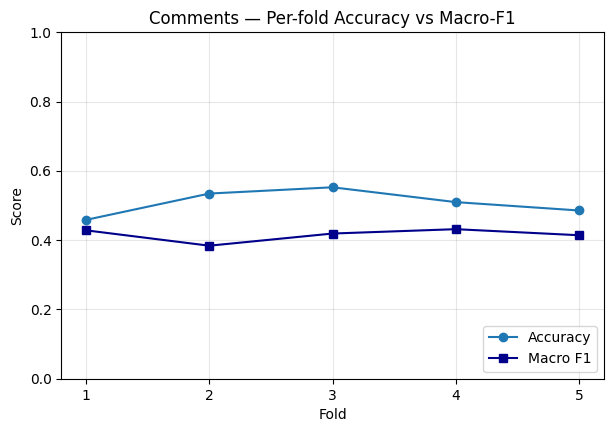

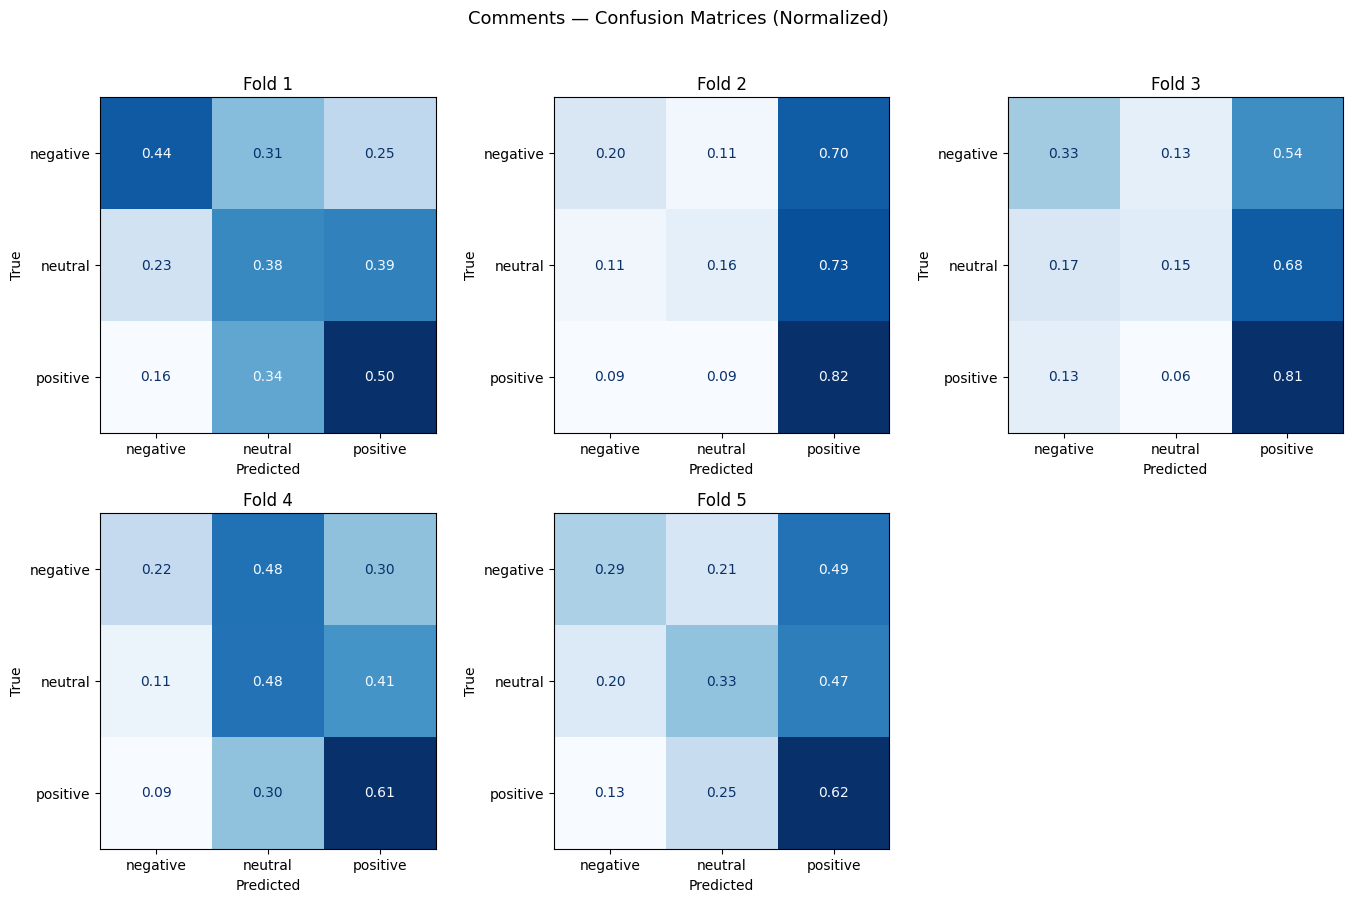

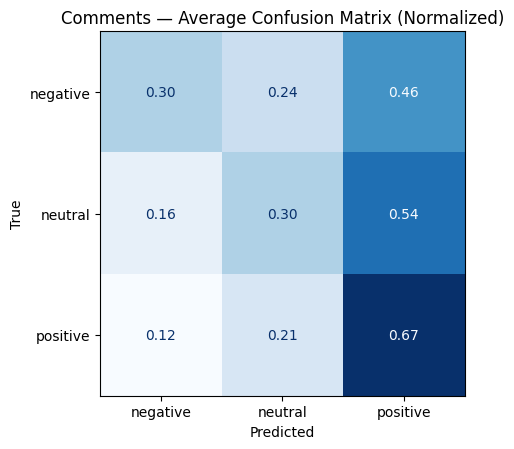

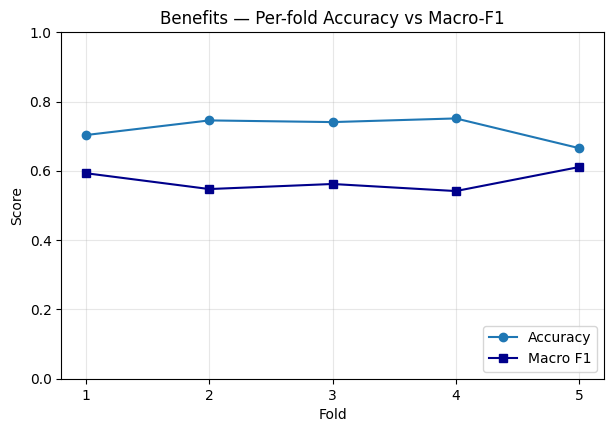

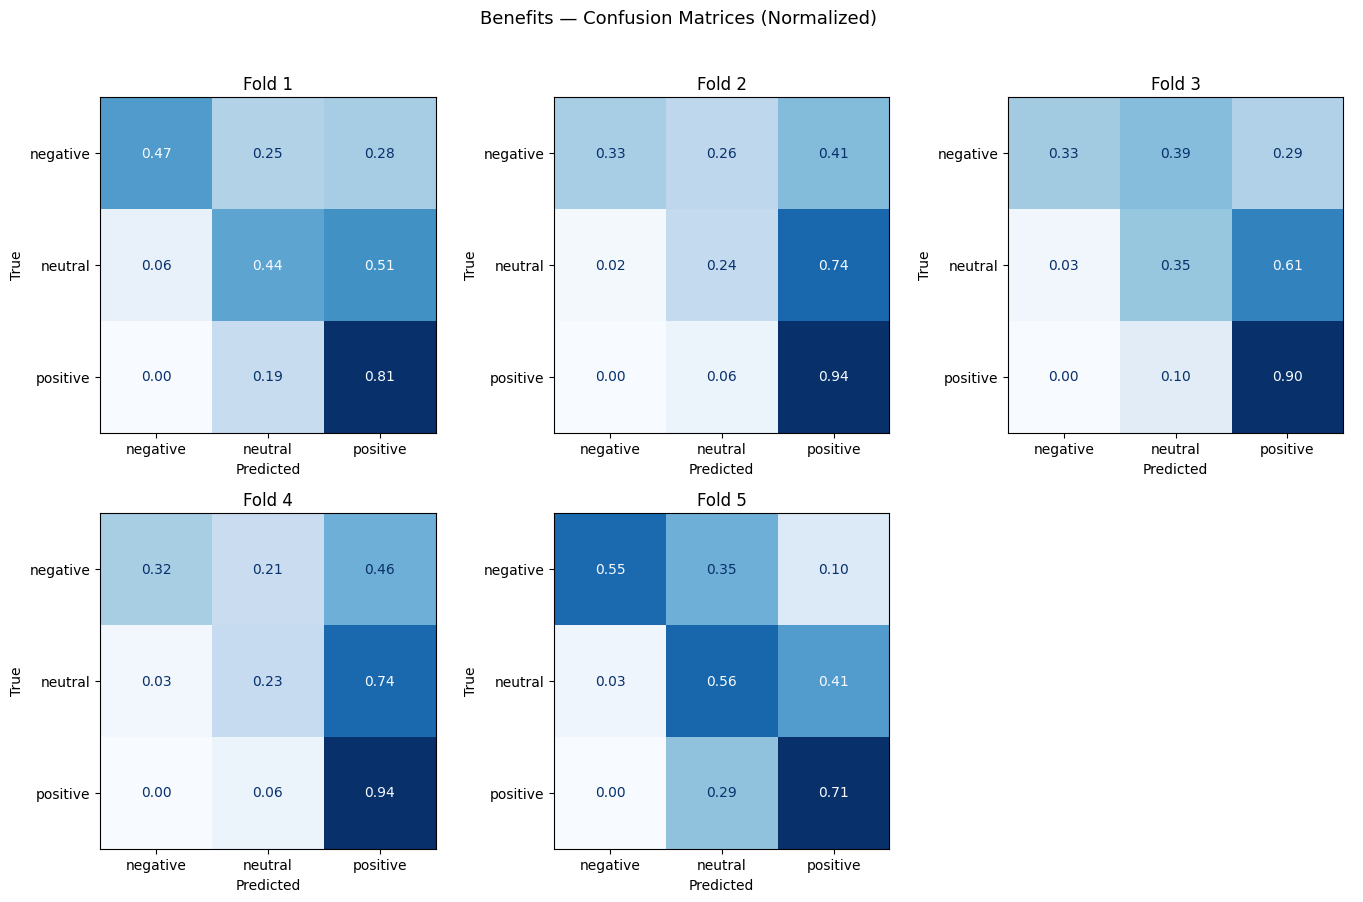

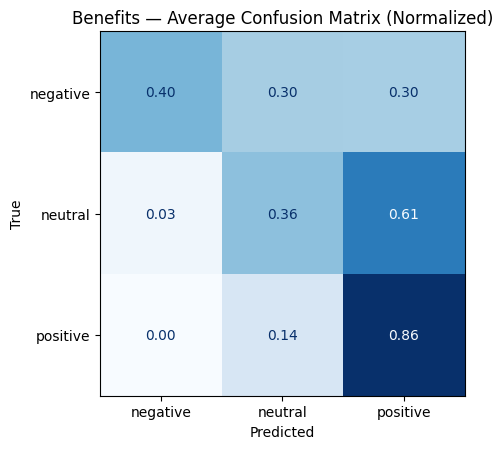

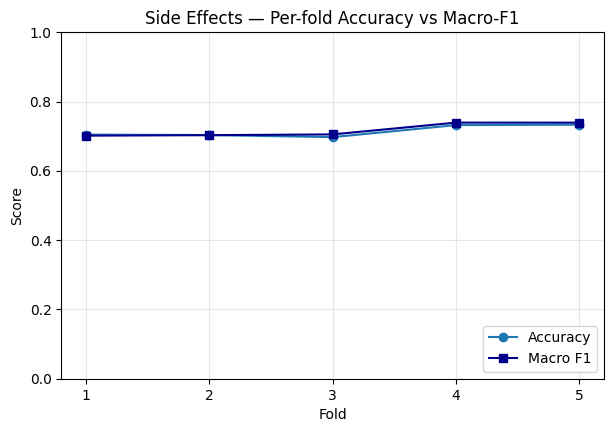

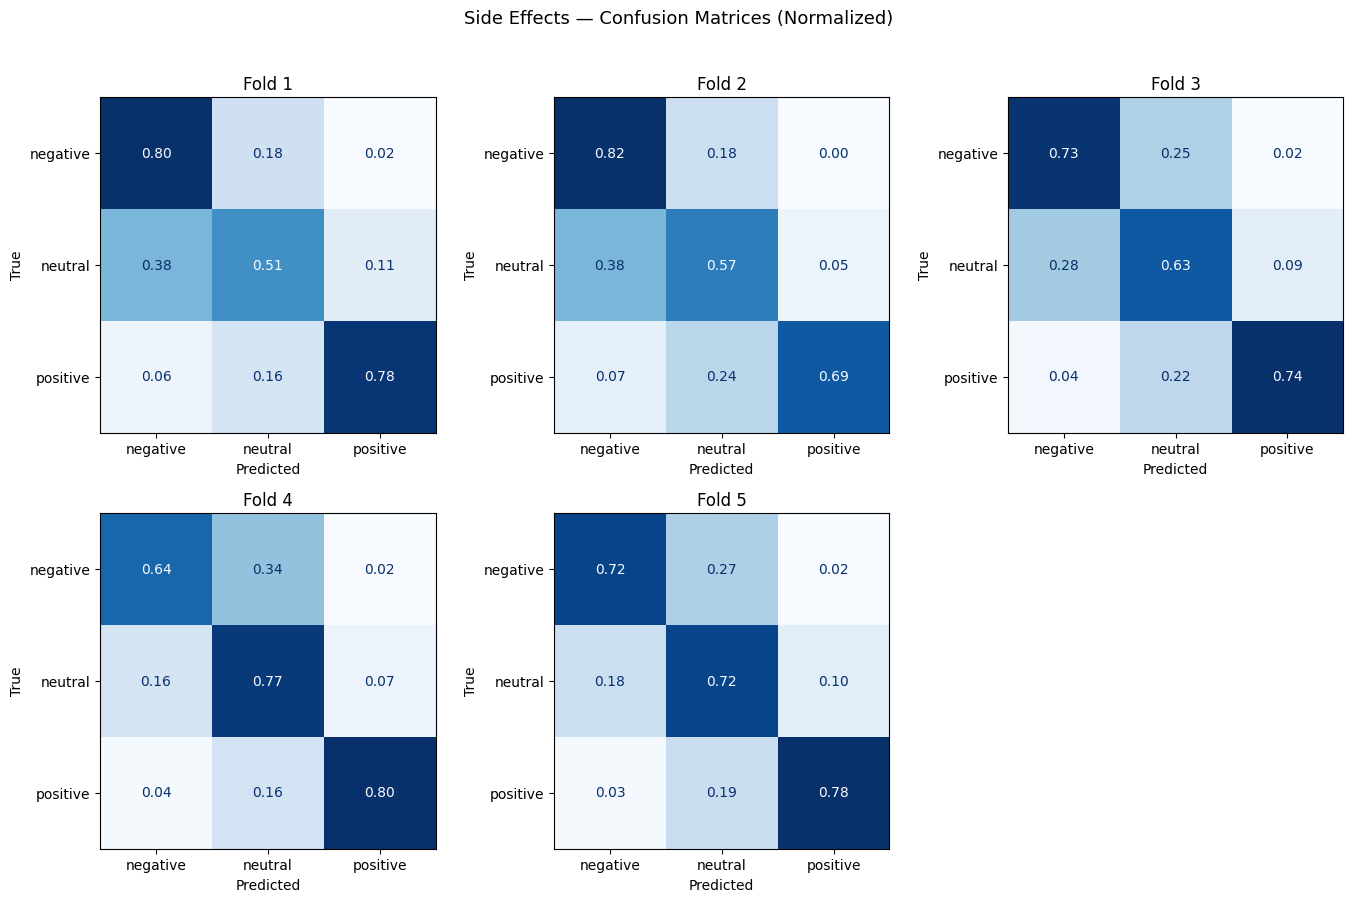

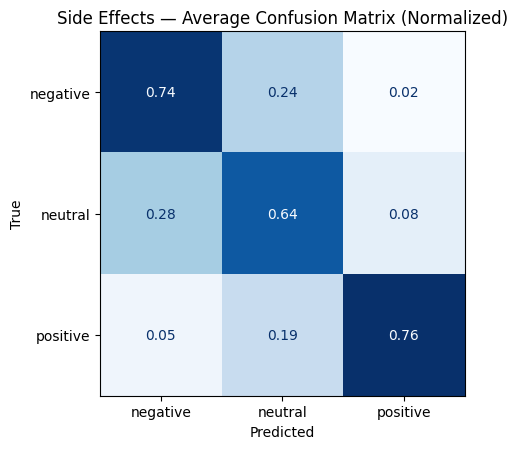

In [ ]:
# 1) Per-aspect visuals (uses your existing accs_*, reports_*, confmats_* objects)
labels = ("negative","neutral","positive")

f1s_c = visualize_aspect(accs_c, reports_c, confmats_c, "Comments", labels=labels)
f1s_b = visualize_aspect(accs_b, reports_b, confmats_b, "Benefits", labels=labels)
f1s_s = visualize_aspect(accs_s, reports_s, confmats_s, "Side Effects", labels=labels)


In [ ]:
# 2) Summary table across folds & aspects
summary_df = build_summary_table(f1s_c, accs_c, f1s_b, accs_b, f1s_s, accs_s)
display(summary_df)

,Model,Fold,Comments (F1/Acc),Benefits (F1/Acc),Side Effects (F1/Acc)
0,CNN-BiLSTM,1,0.4283 / 0.4584,0.5931 / 0.7033,0.7015 / 0.7045
1,CNN-BiLSTM,2,0.3839 / 0.5344,0.5474 / 0.7455,0.7029 / 0.7033
2,CNN-BiLSTM,3,0.4190 / 0.5525,0.5620 / 0.7407,0.7051 / 0.6972
3,CNN-BiLSTM,4,0.4316 / 0.5097,0.5416 / 0.7512,0.7391 / 0.7319
4,CNN-BiLSTM,5,0.4141 / 0.4855,0.6109 / 0.6655,0.7390 / 0.7331
Mean,CNN-BiLSTM,Mean,0.4154 / 0.5081,0.5710 / 0.7212,0.7175 / 0.7140


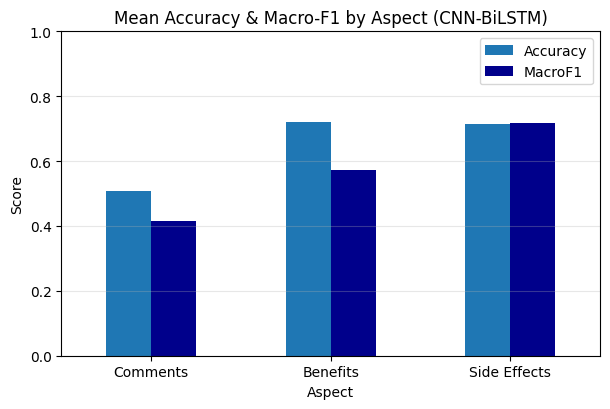

In [ ]:
# 3) Bar chart comparing mean metrics across aspects
means = pd.DataFrame({
    "Aspect": ["Comments","Benefits","Side Effects"],
    "Accuracy": [np.mean(accs_c), np.mean(accs_b), np.mean(accs_s)],
    "MacroF1":  [np.nanmean(f1s_c), np.nanmean(f1s_b), np.nanmean(f1s_s)]
})
ax = means.plot(kind="bar", x="Aspect", rot=0, figsize=(6.2,4.2), color=["#1f77b4", "darkblue"])
ax.set_ylim(0,1)
ax.set_title("Mean Accuracy & Macro-F1 by Aspect (CNN-BiLSTM)")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

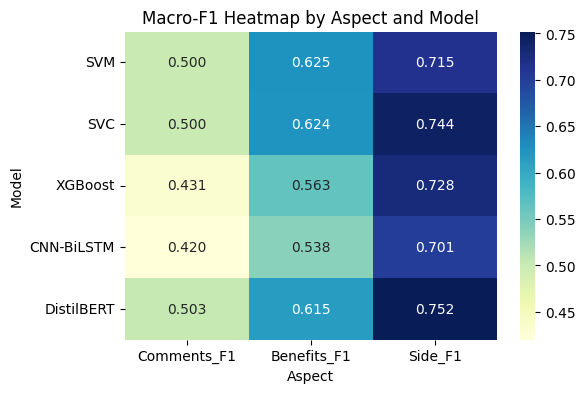

In [ ]:
# Heatmap
import seaborn as sns

# === Define model performance manually (based on your results) ===
data = {
    "Model": ["SVM","SVC","XGBoost","CNN-BiLSTM","DistilBERT"],
    "Comments_F1": [0.5001, 0.5001, 0.4310, 0.4200, 0.5032],
    "Benefits_F1": [0.6250, 0.6240, 0.5629, 0.5380, 0.6145],
    "Side_F1": [0.7148, 0.7441, 0.7284, 0.7010, 0.7519]
}

perf_df = pd.DataFrame(data)

# === Now create heatmap ===
score_matrix = perf_df.set_index("Model")[["Comments_F1","Benefits_F1","Side_F1"]]
plt.figure(figsize=(6,4))
sns.heatmap(score_matrix, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Macro-F1 Heatmap by Aspect and Model")
plt.ylabel("Model")
plt.xlabel("Aspect")
plt.show()

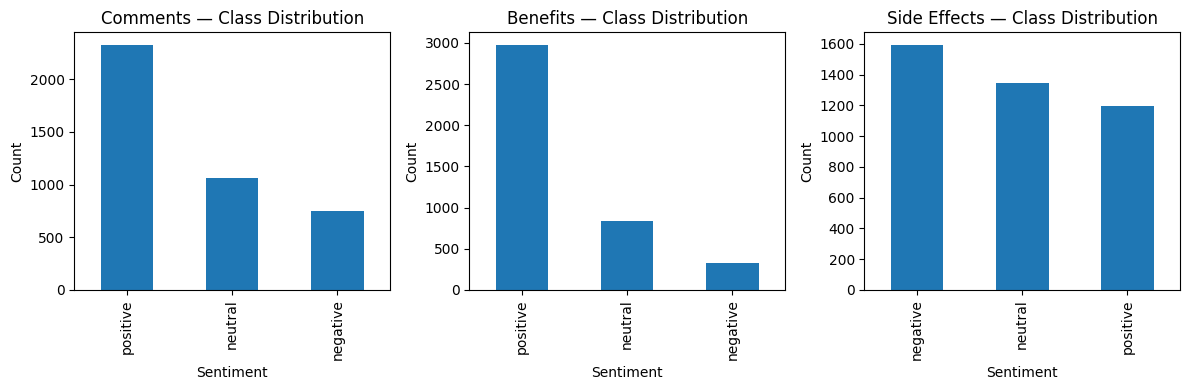

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
for ax,(aspect,label_col) in zip(axes,[("Comments","label_comments"),("Benefits","label_benefits"),("Side Effects","label_side")]):
    df[label_col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"{aspect} — Class Distribution")
    ax.set_xlabel("Sentiment"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
